## Öğrenci Not Analiz Projesi

### Plan/Program:
#### 1. csv dosyasından öğrenci verileri oku
#### 2. temel istatistiksel hesaplamalar
#### 3. filtreleme
#### 4. öğrenci notu görselleştirme
#### 5. OOP ile yapıyı class üzerinde toplama
#### 6. hata yönetimi

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
class OgrenciNotAnalizSistemi:

    def __init__(self, dosya_yolu):
        self.dosya_yolu = dosya_yolu
        self.df = None

    def veriyi_oku(self):
      
        try:
            self.df = pd.read_csv(self.dosya_yolu)

            if self.df.empty:
                raise ValueError("csv dosyası boş")
  
            gerekli_sutunlar = {"isim", "yas", "bolum", "not"}

            if not gerekli_sutunlar.issubset(self.df.columns):
                raise ValueError(
                    f"csv dosyasında gerekli sütunlar eksik"
                    f"Gerekli sütunlar: {gerekli_sutunlar}"
                )
            
            self.df["not"] = pd.to_numeric(self.df["not"], errors = "raise")

            print("Veri başarıyla okundu")
            print(self.df)
        except FileNotFoundError:
            print(f"hata: {self.dosya_yolu} bulunamadı")
        except pd.errors.EmptyDataError:
            print("csv dosyası boş")
        except ValueError as error:
            print(f"hata: {error}")
        except Exception as e:
            print(f"Beklenmeyen hata: {e}")

    def numpy_ile_hesaplama(self):
   
        try:

            if self.df is None: 
                raise ValueError("önce veri yüklenmeli")
            
            notlar = self.df["not"].to_numpy()

            print(f"Ortalama {np.mean(notlar)}")
            print(f"En yüksek not {np.max(notlar)}")
            print(f"En düşük not {np.min(notlar)}")
            print(f"Standart sapma {np.std(notlar)}")
        except ValueError as hata:
            print(f"hata: {hata}")
        except Exception as e:
            print(f"Beklenmeyen bir hata oluştu. {e}")

    def pandas_ile_filtreleme(self):
 
        try:
            if self.df is None:
                raise ValueError("Önce veri okunmalıdır")
            
            print("Pandas ile filtreleme sonuçları")

            yuksek_notlular = self.df[self.df["not"] > 80]
            print(f"Notu 80 den büyük olan öğrenciler: \n{yuksek_notlular}")

            yapay_zeka_ogrencileri = self.df[self.df["bolum"] == "Yapay Zeka"]
            print(f"Bölümü yapay zeka olanlar: \n{yapay_zeka_ogrencileri}")

            yasi_buyuk_olanlar = self.df[self.df["yas"] > 22]
            print(f"22 yaşından büyük olanlar: \n{yasi_buyuk_olanlar}")

        except ValueError as hata:
            print(f"hata: {hata}")
        except Exception as e:
            print(f"BBeklenmeyen bir hata: {e}")

    def grafik_ciz(self):
    
        try:
            if self.df is None:
                raise ValueError("önce veri okunmalı")
            
            plt.figure(figsize=(10, 5))

            plt.bar(self.df["isim"], self.df["not"])
            plt.title("Öğrenci Not Grafiği")
            plt.xlabel("Öğrenci İsimleri")
            plt.ylabel("Notlar")

            plt.tight_layout()

            plt.show()

        except Exception as e:
            print(f"hata: {e}")

    def tum_analizi_calistir(self):

        self.veriyi_oku()

        if self.df is None:
            print("analiz durduruldu")
            return

        self.numpy_ile_hesaplama()

        self.pandas_ile_filtreleme()

        self.grafik_ciz()

In [19]:
dosya_yolu = "ogrenci_notlari.csv"

sistem = OgrenciNotAnalizSistemi(dosya_yolu)

Veri başarıyla okundu
     isim  yas        bolum  not
0     Ali   21   Yapay Zeka   85
1    Ayşe   22  Veri Bilimi   90
2  Mehmet   20   Yapay Zeka   72
3  Zeynep   23      Yazılım   95
4   Ahmet   24  Veri Bilimi   60
5    Elif   22   Yapay Zeka   88
Ortalama 81.66666666666667
En yüksek not 95
En düşük not 60
Standart sapma 11.981467170407619
Pandas ile filtreleme sonuçları
Notu 80 den büyük olan öğrenciler: 
     isim  yas        bolum  not
0     Ali   21   Yapay Zeka   85
1    Ayşe   22  Veri Bilimi   90
3  Zeynep   23      Yazılım   95
5    Elif   22   Yapay Zeka   88
Bölümü yapay zeka olanlar: 
     isim  yas       bolum  not
0     Ali   21  Yapay Zeka   85
2  Mehmet   20  Yapay Zeka   72
5    Elif   22  Yapay Zeka   88
22 yaşından büyük olanlar: 
     isim  yas        bolum  not
3  Zeynep   23      Yazılım   95
4   Ahmet   24  Veri Bilimi   60


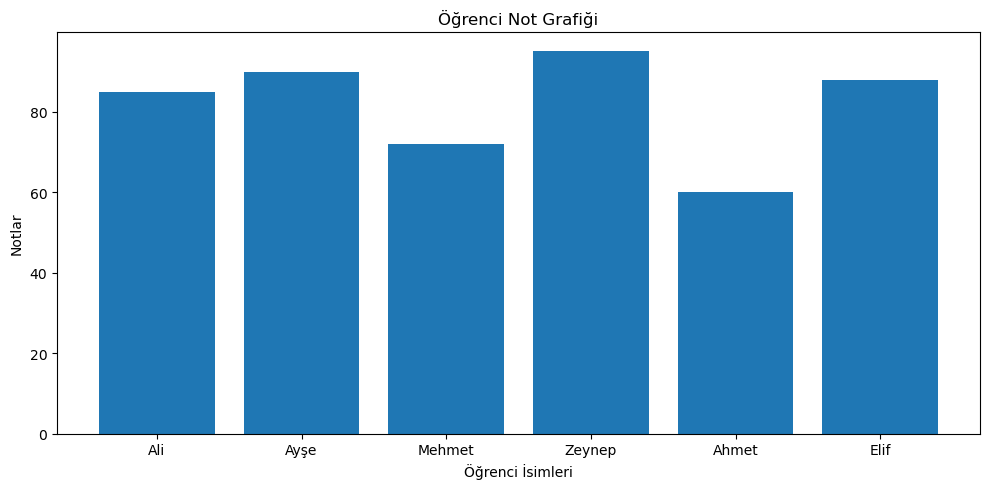

In [21]:
sistem.tum_analizi_calistir()